In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [35]:
df = pd.read_csv("tabla_proyectos_raw.csv")
df

,Id,Activo,Archivado,Nombre,Comunidades,Plantilla,Creador,Usuarios con permiso,Privado,Intereses,Relaciones con perfiles,Grupo desde donde se ha generado,Fecha creación,Fecha actualización,Visitas
0,7652,No,No,Proyecto para Imágenes de guerra,gune+,Personalizada,Susana Mañueco,Paolo Tizón Prado,Sí,NaN,1,NaN,2025-12-02 11:41:28 +0100,2025-12-02 11:41:44 +0100,1
1,7609,Sí,No,ANT-UX: pruebas de usabilidad y adaptación par...,gune+,Konexioak_Prest,Julio Cesar Rivera Pedroza,"José Ignacio Aguirre,Julio Cesar Rivera Pedroz...",Sí,NaN,1,NaN,2025-09-26 00:40:46 +0200,2025-09-28 21:48:34 +0200,58
2,7608,No,No,Enara Nazabal,gune+,Konexioak_Prest,Enara Nazabal Gomez De Segura,"Lorena Vega Durán,Ruth Mayoral,Sara Azurza Esk...",Sí,NaN,1,NaN,2025-09-25 19:02:38 +0200,2026-01-08 14:47:39 +0100,18
3,7607,No,No,Enara Nazabal,gune+,Konexioak_Prest,Enara Nazabal Gomez De Segura,Lorena Vega Durán,Sí,NaN,0,NaN,2025-09-25 18:59:17 +0200,2026-01-08 14:47:40 +0100,2
4,7604,Sí,No,GRALa,gune+,Konexioak_Prest,Maria Iturbe Rey,"Lorena Vega Durán,Maria Iturbe Rey,Ruth Mayora...",Sí,NaN,1,NaN,2025-09-23 19:51:45 +0200,2025-09-24 12:53:27 +0200,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,4544,Sí,Sí,Ficha de proyecto,gune+,Personalizada,Maitane Gómez,"Daniel De Lima,Ruth Mayoral",Sí,NaN,0,NaN,2021-07-13 13:09:09 +0200,2022-06-30 13:09:08 +0200,23
317,4543,Sí,Sí,Ficha de antepropuestas,gune+,Personalizada,Maitane Gómez,"Daniel De Lima,Ruth Mayoral",Sí,NaN,0,NaN,2021-07-13 13:08:34 +0200,2022-06-30 13:08:37 +0200,47
318,4529,Sí,No,Implantación comunidad KSIgune Digital,"Red Urbegi,KSIgune Digital,gune+",Personalizada,Daniel De Lima,"Daniel De Lima,Maitane Gómez",Sí,NaN,0,NaN,2021-07-12 14:01:16 +0200,2022-05-26 17:47:32 +0200,22
319,4450,Sí,No,Implantación comunidad 4gune Digital,"Red Urbegi,gune+",Implantación TGN: Gestión general inicial cliente,Daniel De Lima,"Daniel De Lima,Julieta Barrenechea ,Lorena Veg...",Sí,NaN,0,Grupo del proyecto Implantación comunidad 4gun...,2021-06-29 10:04:54 +0200,2024-09-23 12:12:05 +0200,121


In [36]:
df.columns

Index(['Id', 'Activo', 'Archivado', 'Nombre', 'Comunidades', 'Plantilla',
       'Creador', 'Usuarios con permiso', 'Privado', 'Intereses',
       'Relaciones con perfiles', 'Grupo desde donde se ha generado',
       'Fecha creación', 'Fecha actualización', 'Visitas'],
      dtype='object')

In [37]:
df[df["Activo"] == "Sí"].count()

Id                                  258
Activo                              258
Archivado                           258
Nombre                              258
Comunidades                         258
Plantilla                           258
Creador                             258
Usuarios con permiso                256
Privado                             258
Intereses                            50
Relaciones con perfiles             258
Grupo desde donde se ha generado     18
Fecha creación                      258
Fecha actualización                 258
Visitas                             258
dtype: int64

# 1. Tamaño del ecosistema de proyectos

In [38]:
print("Número total de proyectos:", len(df))

print("\nProyectos activos:")
print(df["Activo"].value_counts())

print("\nProyectos archivados:")
print(df["Archivado"].value_counts())

print("\nProyectos privados:")
print(df["Privado"].value_counts())

Número total de proyectos: 321

Proyectos activos:
Activo
Sí    258
No     63
Name: count, dtype: int64

Proyectos archivados:
Archivado
No    256
Sí     65
Name: count, dtype: int64

Proyectos privados:
Privado
Sí    294
No     27
Name: count, dtype: int64


C:\Users\Acer\AppData\Local\Temp\ipykernel_1168\2340878507.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Privado", data=df, palette=colors)


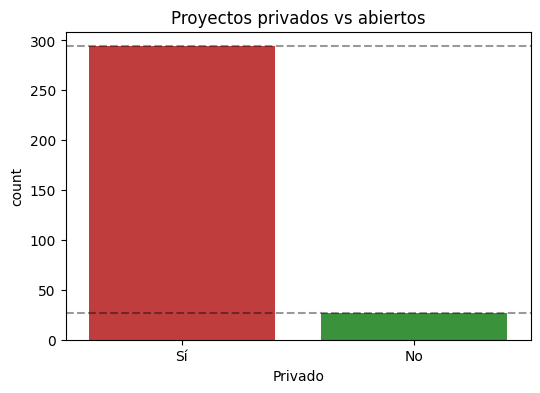

In [39]:
plt.figure(figsize=(6,4))
colors = {
    "Sí": "#d62728",   # rojo (privado)
    "No": "#2ca02c"    # verde (abierto)
}
sns.countplot(x="Privado", data=df, palette=colors)
plt.title("Proyectos privados vs abiertos")
plt.axhline(y=294, linestyle="--", color="black", alpha=0.4)
plt.axhline(y=27, linestyle="--", color="black", alpha=0.4)
plt.show()

# 2. Actividad de los proyectos (visitas)

In [40]:
df["Visitas"] = pd.to_numeric(df["Visitas"], errors="coerce")

print(df["Visitas"].describe())

count    321.000000
mean      55.984424
std       61.011396
min        1.000000
25%        9.000000
50%       34.000000
75%       80.000000
max      321.000000
Name: Visitas, dtype: float64


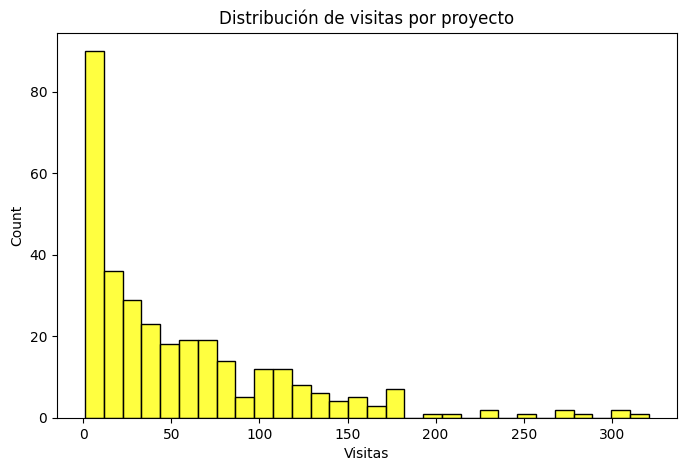

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(df["Visitas"], bins=30, color="yellow")
plt.title("Distribución de visitas por proyecto")
plt.xlabel("Visitas")
plt.show()

In [42]:
top_visitas = df.sort_values("Visitas", ascending=False)[
    ["Nombre", "Visitas", "Creador"]
].head(10)

top_visitas

,Nombre,Visitas,Creador
201,REVALORIZACIÓN DEL PATRIMONIO CONSTRUIDO A TRA...,321,María Senderos Laca
154,Crystal Mine: matriz para un modelo de distrib...,307,Marina Arranz
119,Mizelioa,304,Gorka Legarra Atxurra
266,SISTEMA PILOTO PARA PROMOVER LA COHERENCIA AMB...,284,María Senderos Laca
62,ABUSUEN KONTRAKO PROTOKOLOA IKUSENTZUNEZKO IND...,271,Itxaso Del Castillo Aira
92,EMIAK: Plataforma de Detección de Sesgos de Gé...,270,Alejandra Bueno
175,IKERKUNTZA SUSPERTU,249,Eneko Besa
73,LLM sortzaileek euskaraz erakusten dituzten al...,233,Xabier Saralegi
108,SCOBY TISSUES,225,Marina Arranz
136,(Timbre). Laboratorio para el desarrollo de un...,214,Marina Arranz


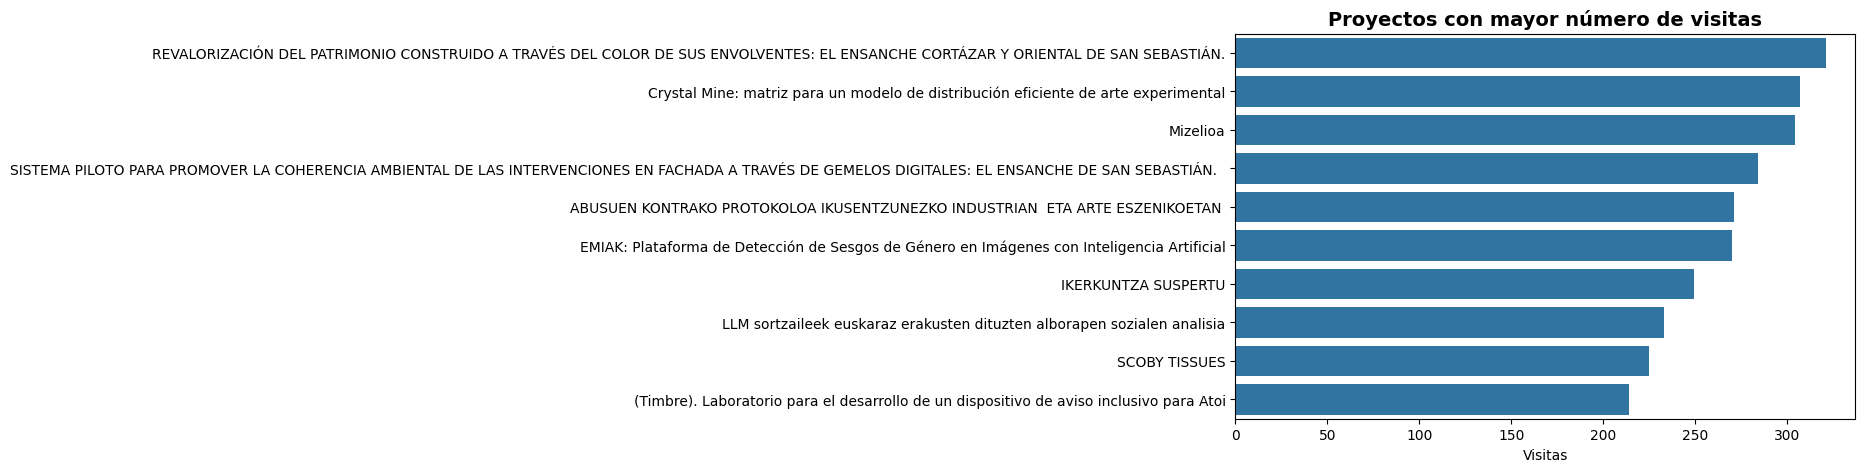

In [43]:
top_projects = df.sort_values("Visitas", ascending=False).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    y=top_projects["Nombre"],
    x=top_projects["Visitas"]
)

plt.title(
    "Proyectos con mayor número de visitas",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Visitas")
plt.ylabel("")

plt.show()

# 3. Colaboración en proyectos

In [ ]:
df["n_usuarios"] = df["Usuarios con permiso"].apply(
    lambda x: len(str(x).split(",")) if pd.notna(x) else 0
)

df["n_usuarios"].describe()

count    321.000000
mean       4.510903
std        3.468705
min        0.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       35.000000
Name: n_usuarios, dtype: float64

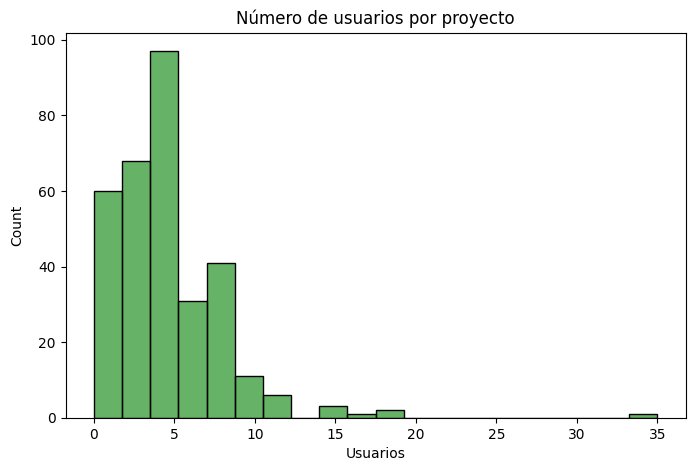

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["n_usuarios"], bins=20, color="green", alpha=0.6)
plt.title("Número de usuarios por proyecto")
plt.xlabel("Usuarios")
plt.show()

In [ ]:
top_proyectos_con_mas_usuarios = df.sort_values("n_usuarios", ascending=False)[
    ["Nombre", "n_usuarios", "Creador"]
].head(10)

top_proyectos_con_mas_usuarios

,Nombre,n_usuarios,Creador
233,Desarrollo de Trabajos de Fin de Grado (TFG) y...,35,Oihane Sánchez Duro
62,ABUSUEN KONTRAKO PROTOKOLOA IKUSENTZUNEZKO IND...,19,Itxaso Del Castillo Aira
320,Crea tu primer proyecto en equipo,19,Daniel De Lima
267,"Proyecto IDIMORE: Investigación, DIseño y desa...",16,Iker Laskurain
288,El coche del futuro,15,Rodrigo Martínez Rodríguez
295,UPCYCLING PET INTO VALUABLE PRODUCTS. LCA ANAL...,14,Maider Iturrondobeitia Ellacuria
75,KultUrekin - Kultur lidergotza eta ekintzailet...,14,Garazi Egiguren Urkola
73,LLM sortzaileek euskaraz erakusten dituzten al...,12,Xabier Saralegi
119,Mizelioa,12,Gorka Legarra Atxurra
66,Dabadaba Agency,12,Sebastian Sallaberry


# 4. Evolución de proyectos

In [ ]:
df["Fecha creación"].notna().mean()

np.float64(1.0)

In [ ]:
df["Fecha creación"].value_counts().head(10)

Fecha creación
2025-12-02 11:41:28 +0100    1
2025-09-26 00:40:46 +0200    1
2025-09-25 19:02:38 +0200    1
2025-09-25 18:59:17 +0200    1
2025-09-23 19:51:45 +0200    1
2025-09-23 18:47:24 +0200    1
2025-09-22 11:47:15 +0200    1
2025-09-16 20:09:44 +0200    1
2025-09-15 13:18:08 +0200    1
2025-09-15 09:17:08 +0200    1
Name: count, dtype: int64

In [ ]:
df["Fecha creación"] = pd.to_datetime(
    df["Fecha creación"].astype(str).str[:19],  # nos quedamos solo con YYYY-MM-DD HH:MM:SS
    errors="coerce"
)

df["mes_creacion"] = df["Fecha creación"].dt.to_period("M")

proyectos_mes = df.groupby("mes_creacion").size()
proyectos_mes.index = proyectos_mes.index.to_timestamp()

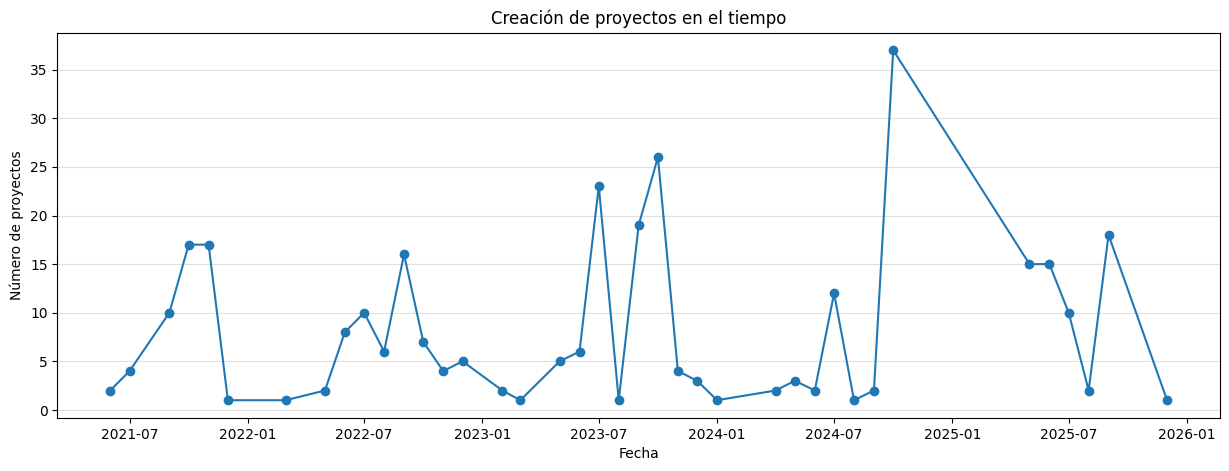

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(proyectos_mes.index, proyectos_mes.values, marker="o")

plt.title("Creación de proyectos en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Número de proyectos")
plt.grid(axis='y', alpha=0.4)

plt.show()

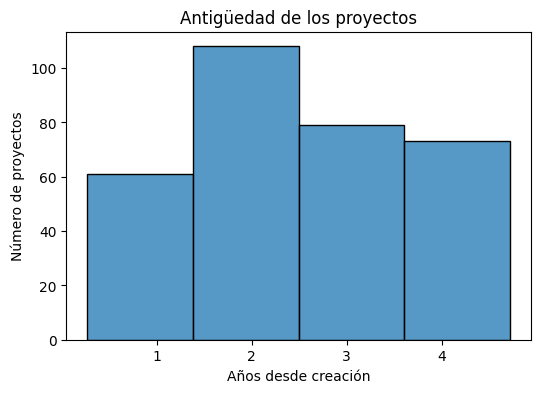

In [ ]:
# Antiguedad de los proyectos

df["años_proyecto"] = (
    pd.Timestamp.today() - df["Fecha creación"]
).dt.days / 365

plt.figure(figsize=(6,4))

sns.histplot(df["años_proyecto"], bins=4)

plt.title("Antigüedad de los proyectos")
plt.xlabel("Años desde creación")
plt.ylabel("Número de proyectos")

plt.show()

# 5. Estado actual de los proyectos

In [ ]:
# Convertir a datetime
df["Fecha actualización"] = pd.to_datetime(
    df["Fecha actualización"],
    errors="coerce",
    utc=True
)

# Quitar timezone
df["Fecha actualización"] = df["Fecha actualización"].dt.tz_convert(None)

# Calcular días sin actualizar
df["dias_sin_actualizar"] = (
    pd.Timestamp.today() - df["Fecha actualización"]
).dt.days

In [ ]:
# Clasificación inicial
df["estado_proyecto"] = pd.cut(
    df["dias_sin_actualizar"],
    bins=[-1,90,180,9999],
    labels=["Activo","Dormido","Abandonado"]
)

# Añadir nueva categoría
df["estado_proyecto"] = df["estado_proyecto"].cat.add_categories("Sin registro")

# Asignar proyectos sin fecha
df.loc[df["dias_sin_actualizar"].isna(), "estado_proyecto"] = "Sin registro"

In [ ]:
print(df["dias_sin_actualizar"].isna().sum())
print(df["Fecha actualización"].isna().sum())

0
0


C:\Users\Acer\AppData\Local\Temp\ipykernel_1168\201197550.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


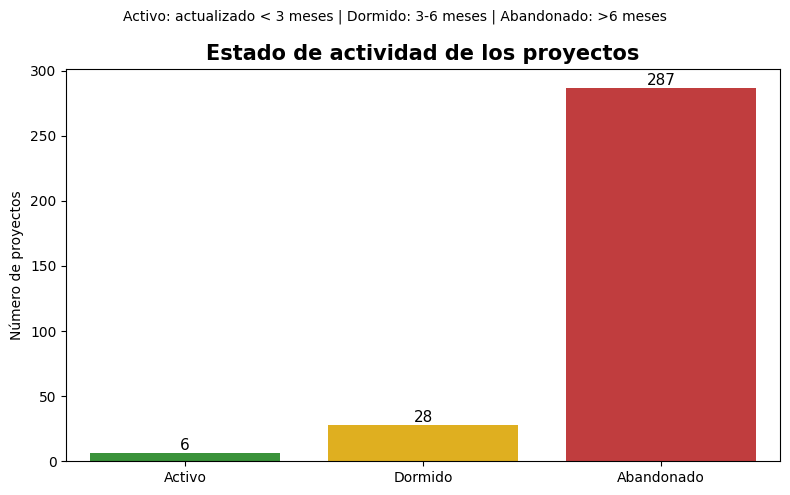

In [ ]:
plt.figure(figsize=(8,5))

colors = {
    "Activo": "#2ca02c",       # verde
    "Dormido": "#ffbf00",      # amarillo
    "Abandonado": "#d62728"    # rojo
}

ax = sns.countplot(
    x="estado_proyecto",
    data=df,
    order=["Activo","Dormido","Abandonado"],
    palette=colors
)

plt.title(
    "Estado de actividad de los proyectos",
    fontsize=15,
    fontweight="bold"
)

plt.suptitle(
    "Activo: actualizado < 3 meses | Dormido: 3-6 meses | Abandonado: >6 meses",
    fontsize=10
)

plt.xlabel("")
plt.ylabel("Número de proyectos")

# etiquetas encima de las barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

# 6. ¿Quién crea los proyectos?

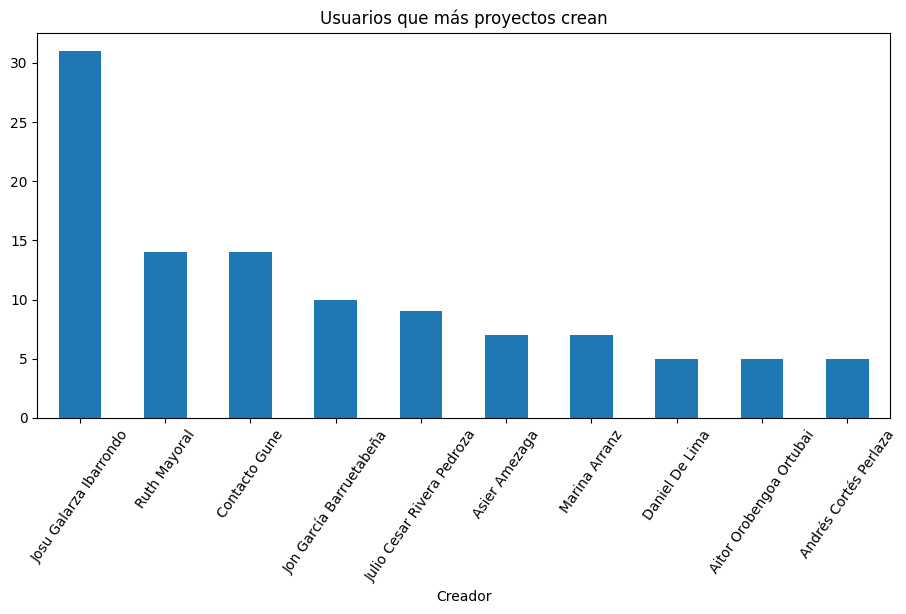

In [ ]:
creadores = df["Creador"].value_counts().head(10)

plt.figure(figsize=(11,5))
creadores.plot(kind="bar")
plt.title("Usuarios que más proyectos crean")
plt.xticks(rotation=55)
plt.show()

# 7. Relación entre colaboración e interés en los proyectos

In [ ]:
df["num_usuarios"] = df["Usuarios con permiso"].fillna("").apply(
    lambda x: len(str(x).split(","))
)

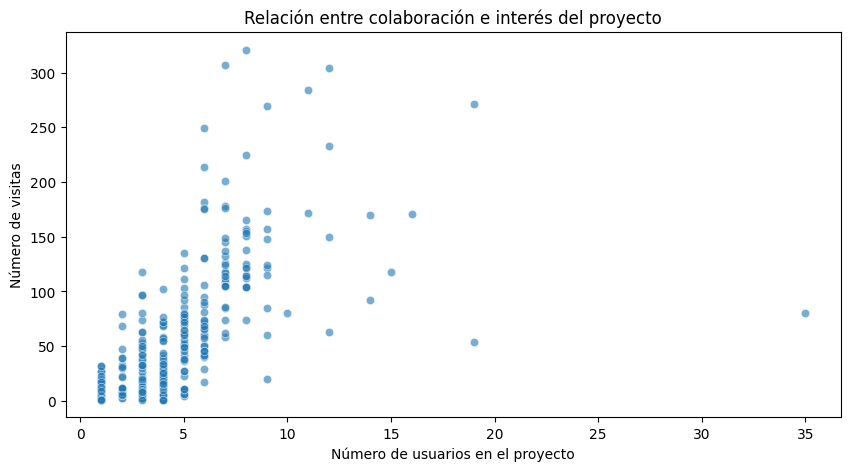

In [ ]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="num_usuarios",
    y="Visitas",
    alpha=0.6
)

plt.title("Relación entre colaboración e interés del proyecto")
plt.xlabel("Número de usuarios en el proyecto")
plt.ylabel("Número de visitas")

plt.show()

# Conclusiones del análisis de proyectos en Gune+

### 1. Alta creación de proyectos, pero baja actividad sostenida

El análisis temporal muestra que se han creado numerosos proyectos a lo largo del tiempo, con algunos picos de creación en determinados periodos. Sin embargo, el estado actual indica que solo una parte muy pequeña de los proyectos mantiene actividad reciente, mientras que la gran mayoría se encuentran abandonados o sin actualizaciones.

### 2. La actividad se concentra en pocos proyectos

La distribución de visitas muestra una asimetría muy marcada: la mayoría de los proyectos reciben pocas visitas, mientras que un número reducido concentra gran parte del interés dentro de la comunidad. Esto sugiere que solo algunos proyectos consiguen generar visibilidad y participación real.

### 3. Los proyectos suelen tener equipos pequeños

El análisis del número de usuarios por proyecto muestra que la mayoría de proyectos cuentan con equipos reducidos, normalmente entre 2 y 6 personas. Los proyectos con equipos más grandes son excepcionales, lo que indica que la colaboración suele producirse en grupos pequeños.

### 4. Existencia de usuarios altamente dinamizadores

El gráfico de creadores de proyectos revela que un número reducido de usuarios concentra una parte importante de la creación de proyectos. Esto sugiere la existencia de perfiles particularmente activos que actúan como dinamizadores dentro de la comunidad.

### 5. Predominio de proyectos privados

La gran mayoría de los proyectos son privados, lo que indica que la plataforma se utiliza principalmente como espacio de trabajo para equipos concretos más que como repositorio abierto de iniciativas accesibles a toda la comunidad.

### Lectura global del ecosistema

En conjunto, los resultados sugieren que el ecosistema de proyectos presenta una estructura típica de comunidades digitales:

- muchos proyectos creados

- pocos proyectos realmente activos

- actividad concentrada en un número reducido de iniciativas

- participación impulsada por un grupo pequeño de usuarios especialmente activos

Este patrón indica que existe capacidad de generación de iniciativas, pero también oportunidades para mejorar la continuidad de los proyectos y ampliar la participación en aquellos que generan mayor interés dentro de la comunidad.

# B ¿Hay diferencia de participación de proyectos entre tipos de usuarios?

In [ ]:
df2 = pd.read_csv("users-2026-03-11.csv")

In [ ]:
df2

,Id,Nombre,Email,Comunidades,Activo,Bloqueado,Admin,Registrado mediante api,Estado,App móvil,...,Actividades,Perfiles.1,Proyectos.1,Conversaciones.1,Actividades.1,Última conexión,Visitas a contenidos,Recurrencia,Conexiones,Días
0,34388,Marisa Lafuente Rodríguez,info@lailusa.com,gune+,Sí,No,No,No,Completo,No,...,0,Marisa Lafuente Rodríguez,NaN,NaN,NaN,10/03/2026,1,50.0%,1,2
1,34387,Irantzu Lekue,iralekue@gmail.com,gune+,Sí,No,No,No,Completo,No,...,0,Irantzu Lekue,NaN,NaN,NaN,10/03/2026,4,50.0%,1,2
2,34383,Bd Praktikak,bdpraktikak@idarte.eus,gune+,Sí,No,No,No,Completo,No,...,0,Bd Praktikak,NaN,NaN,NaN,10/03/2026,5,50.0%,1,2
3,34382,Agata Kobuszewska,adm.sakuradojo@gmail.com,gune+,No,No,No,No,Dado de baja desde el admin,No,...,0,NaN,NaN,NaN,NaN,10/03/2026,0,50.0%,1,2
4,34360,Yara Otero Echazarreta,yotero002@ikasle.ehu.eus,gune+,Sí,No,No,No,Completo,No,...,0,Yara Otero Echazarreta,NaN,NaN,NaN,06/03/2026,8,16.67%,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
832,295,Maria Saiz Santos,maria.saiz@ehu.eus,"Comunidad Agentes SAREKIN,BBK bizkaia.network,...",Sí,No,No,No,Completo,Sí,...,1,"Universidad del País Vasco UPV/EHU, Maria Saiz...",NaN,"Friendly startups , Presentación del proyecto ...",Cultura emprendedora,07/07/2025,222,56.35%,1828,3244
833,163,Aitzol Batiz,abatiz@kultiba.net,"gune+,BBK bizkaia.network",Sí,No,No,No,Completo,No,...,0,"KULTIBA cambios culturales, AISILAN XXI, S.L.",Sesión de participación II Plan Terrirtorial S...,"Friendly startups , Todo sobre Emprendimiento ...",NaN,06/09/2024,233,0.9%,30,3327
834,90,Laxmi Nazabal,laxmi@mukalab.com,"BBK bizkaia.network,gune+",Sí,No,No,No,Completo,No,...,0,"Muka Design Lab, Laxmi Nazabal Gaztañaga",Muka Design Lab,"Friendly startups , Información para emprended...",NaN,13/07/2023,349,2.17%,74,3411
835,3,Pablo Ocaña,pablo@urbegi.com,"Anezka,YMCA La Rioja,CEAJE,Diabetes MX,Hub de ...",Sí,No,Sí,No,Completo,Sí,...,28,"Pablo Ocaña, BBK bizkaia.network, Grupo Urbegi...",Gestión. Estrategia e innovación USI ( Urbeg...,Presentación de Pablo Ocaña zitek - Bizkaia ta...,"Programa ' Hola hola' , ASK me anything Mark S...",12/02/2026,66762,100.0%,8095,3674


In [ ]:
df2[df2["Proyectos.1"] == pd.isna].value_counts()

Id                                   0
Nombre                               0
Email                                0
Comunidades                          0
Activo                               0
Bloqueado                            0
Admin                                0
Registrado mediante api              0
Estado                               0
App móvil                            0
Guía                                 0
Sexo                                 0
Año de nacimiento                  0.0
Procedencia                          0
Código postal                      0.0
Canales a los que está suscrito      0
Experto en                           0
Perfil principal                     0
Categorías del perfil                0
Perfiles                             0
Proyectos                            0
Conversaciones                       0
Actividades                          0
Perfiles.1                           0
Proyectos.1                          0
Conversaciones.1         